# CRISP-DM Pipeline: Predicting Fraud in E-Commerce Orders

**IS 455 — Machine Learning in Python**  
**Dataset:** `shop.db` (SQLite)

---

## Table of Contents
1. [Business Understanding](#1)
2. [Data Understanding](#2)
3. [Data Preparation](#3)
4. [Modeling](#4)
5. [Evaluation](#5)
6. [Feature Selection](#6)
7. [Deployment](#7)

<a id='1'></a>
## 1. Business Understanding

### Problem Statement
Our e-commerce platform processes thousands of orders. A small but costly fraction of these orders turn out to be fraudulent. The business needs a model that can **predict whether a given order is fraudulent (`is_fraud = 1`)** so that the warehouse and fulfillment teams can flag high-risk orders for manual review before shipping.

### Success Criteria
- **Primary metric: Recall (Sensitivity)** — we want to catch as many fraudulent orders as possible, even at the cost of some false positives. Missing a fraudulent order is more expensive than reviewing a legitimate one.
- **Secondary metric: F1-Score** — balances precision and recall so we don’t overwhelm the review team with too many false alarms.
- **Baseline:** A naïve model that predicts every order as non-fraud achieves ~93.6% accuracy but 0% recall on fraud. Any useful model must substantially beat this.

### Key Business Questions
1. Which order and customer features are most predictive of fraud?
2. Can the model generalize to unseen orders with acceptable recall?
3. How can we serialize the model for real-time scoring in our web application?

<a id='2'></a>
## 2. Data Understanding

We load data directly from the `shop.db` SQLite database using the shared `data_preparation` module in `jobs/`. This keeps the data loading logic consistent between the notebook and the production inference script.

In [38]:
import sys, os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

sys.path.insert(0, os.path.join(os.getcwd(), 'jobs'))
from data_preparation import load_tables, engineer_features, build_preprocessor
from data_preparation import ALL_FEATURES, NUMERIC_FEATURES, CATEGORICAL_FEATURES

DB_PATH = 'shop.db'
tables = load_tables(DB_PATH)
for name, tbl in tables.items():
    print(f'{name:15s}: {tbl.shape}')

orders         : (5000, 17)
customers      : (250, 12)
order_items    : (15022, 6)
shipments      : (5000, 9)


In [39]:
orders = tables['orders']
print('=== orders.info() ===')
orders.info()
print()
orders.describe(include='all').T

=== orders.info() ===
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        5000 non-null   int64  
 1   customer_id     5000 non-null   int64  
 2   order_datetime  5000 non-null   str    
 3   billing_zip     5000 non-null   str    
 4   shipping_zip    5000 non-null   str    
 5   shipping_state  5000 non-null   str    
 6   payment_method  5000 non-null   str    
 7   device_type     5000 non-null   str    
 8   ip_country      5000 non-null   str    
 9   promo_used      5000 non-null   int64  
 10  promo_code      1261 non-null   str    
 11  order_subtotal  5000 non-null   float64
 12  shipping_fee    5000 non-null   float64
 13  tax_amount      5000 non-null   float64
 14  order_total     5000 non-null   float64
 15  risk_score      5000 non-null   float64
 16  is_fraud        5000 non-null   int64  
dtypes: float64(5), int64(4

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,5000.0,NaN,NaN,NaN,2500.5,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
customer_id,5000.0,NaN,NaN,NaN,28.4482,49.086939,1.0,2.0,6.0,28.0,250.0
order_datetime,5000,5000,2025-11-29 00:51:07,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
billing_zip,5000,243,28289,1156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shipping_zip,5000,630,28289,1058,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shipping_state,5000,18,CO,1702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
payment_method,5000,4,card,3128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
device_type,5000,3,mobile,2734,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ip_country,5000,6,US,4496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
promo_used,5000.0,NaN,NaN,NaN,0.2522,0.434319,0.0,0.0,0.0,1.0,1.0


Target distribution (is_fraud):
is_fraud
0    4682
1     318
Name: count, dtype: int64

Fraud rate: 6.36%


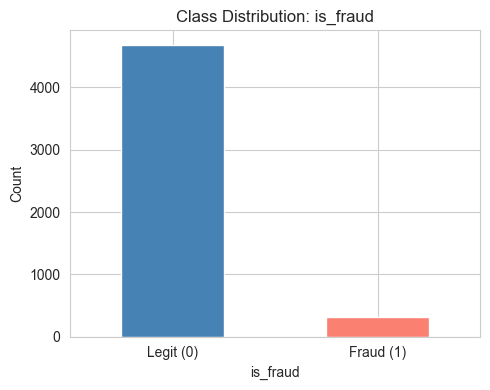

In [40]:
print('Target distribution (is_fraud):')
print(orders['is_fraud'].value_counts())
print(f'\nFraud rate: {orders["is_fraud"].mean():.2%}')

fig, ax = plt.subplots(figsize=(5, 4))
orders['is_fraud'].value_counts().plot.bar(ax=ax, color=['steelblue', 'salmon'])
ax.set_title('Class Distribution: is_fraud')
ax.set_xticklabels(['Legit (0)', 'Fraud (1)'], rotation=0)
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 2.1 Feature-Level Exploration (Ch. 6)

We explore the distributions of key numeric and categorical columns.

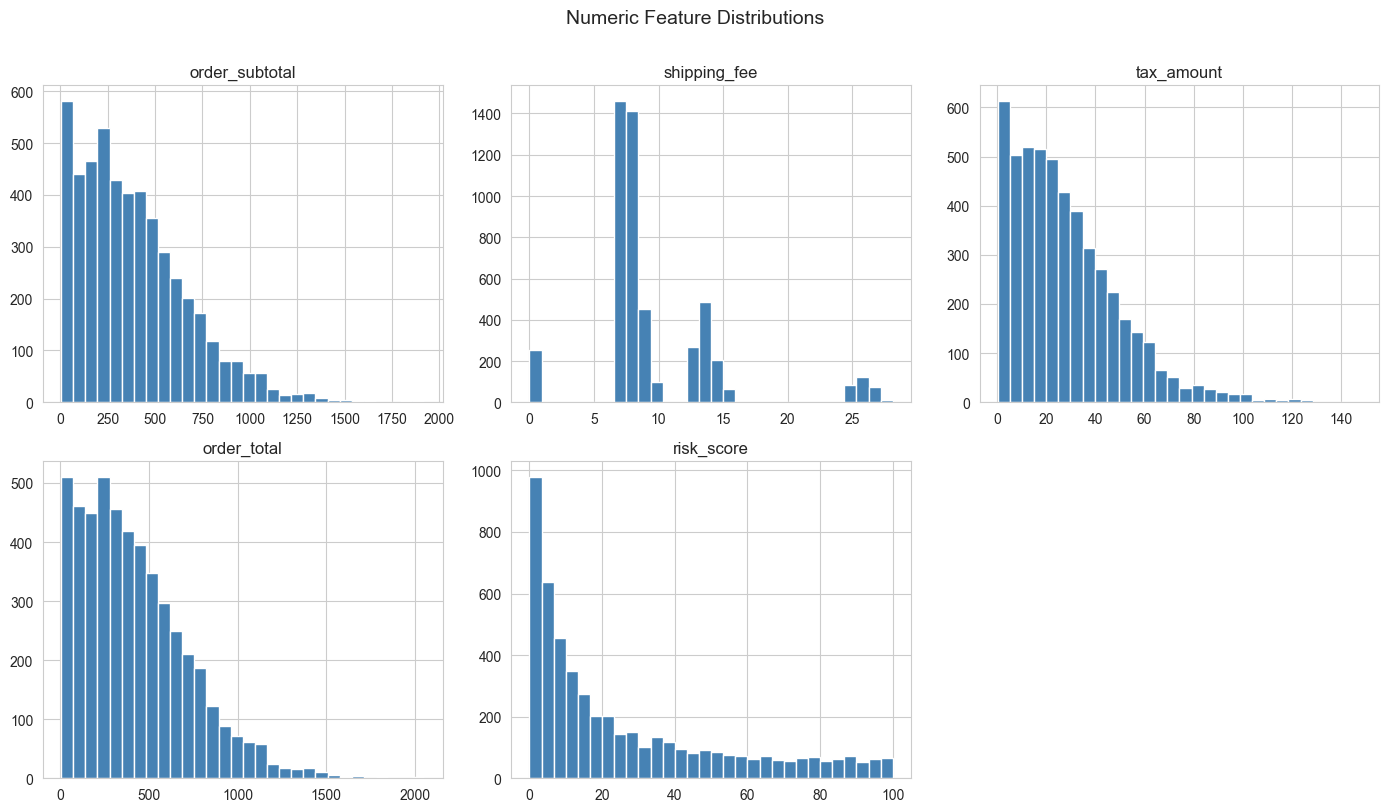

In [41]:
num_cols = ['order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'risk_score']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(num_cols):
    ax = axes.flat[i]
    orders[col].hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
axes.flat[-1].set_visible(False)
plt.suptitle('Numeric Feature Distributions', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

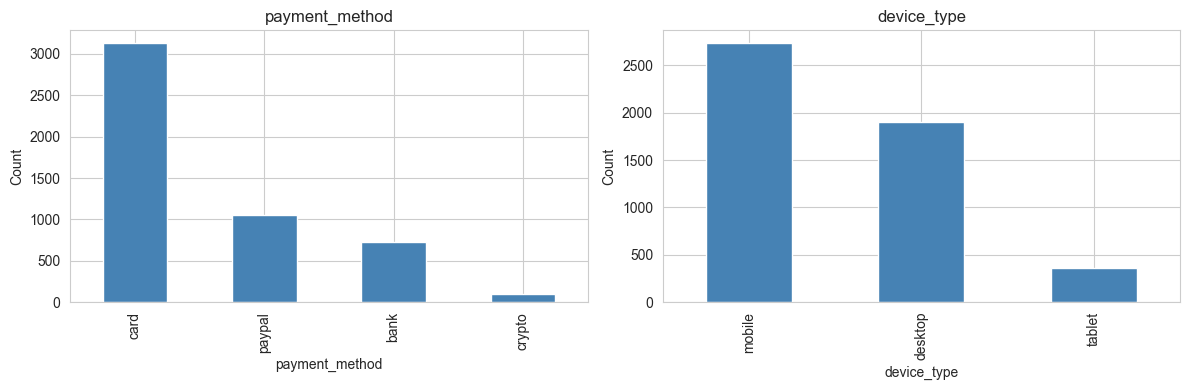

In [42]:
cat_cols = ['payment_method', 'device_type']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, cat_cols):
    orders[col].value_counts().plot.bar(ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### 2.2 Discovering Relationships (Ch. 8)

We look at how numeric features correlate and how they differ between fraud and non-fraud orders.

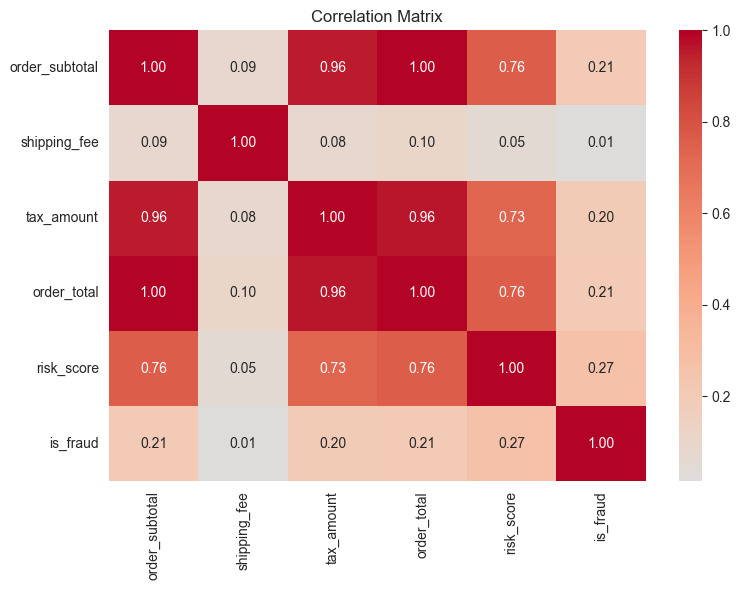

In [43]:
corr = orders[num_cols + ['is_fraud']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

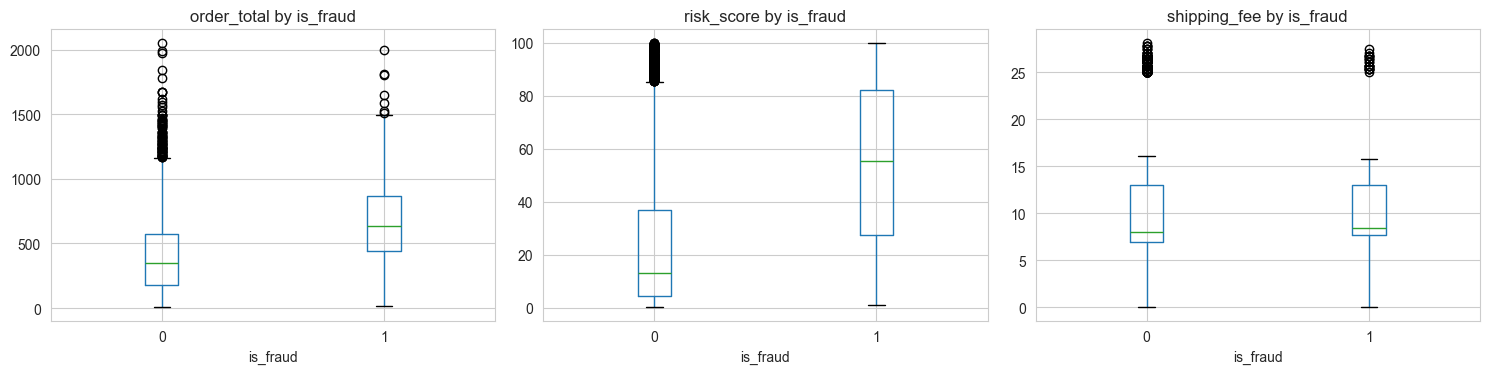

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['order_total', 'risk_score', 'shipping_fee']):
    orders.boxplot(column=col, by='is_fraud', ax=ax)
    ax.set_title(f'{col} by is_fraud')
    ax.set_xlabel('is_fraud')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [45]:
print('Fraud rate by payment method:')
print(orders.groupby('payment_method')['is_fraud'].mean().sort_values(ascending=False))
print('\nFraud rate by device type:')
print(orders.groupby('device_type')['is_fraud'].mean().sort_values(ascending=False))

Fraud rate by payment method:
payment_method
crypto    0.103093
card      0.067455
bank      0.059310
paypal    0.051429
Name: is_fraud, dtype: float64

Fraud rate by device type:
device_type
mobile     0.068032
tablet     0.065934
desktop    0.056782
Name: is_fraud, dtype: float64


<a id='3'></a>
## 3. Data Preparation (Ch. 2–4, 7)

We use the shared `engineer_features()` function from `jobs/data_preparation.py` for consistent feature engineering across the notebook and the deployed inference pipeline. We then build an automated preprocessing pipeline using `ColumnTransformer`.

In [46]:
df = engineer_features(tables)
print(f'Engineered dataframe shape: {df.shape}')
print(f'\nNew features added:')
new_feats = ['order_hour', 'order_dow', 'is_weekend', 'zip_mismatch',
             'is_international', 'subtotal_ratio', 'log_order_total',
             'item_count', 'total_qty', 'avg_unit_price', 'unique_products']
df[new_feats].describe().T

Engineered dataframe shape: (5000, 32)

New features added:


,count,mean,std,min,25%,50%,75%,max
order_hour,5000.0,11.544200,6.955381,0.000000,5.000000,12.000000,18.000000,23.000000
order_dow,5000.0,3.026800,2.004117,0.000000,1.000000,3.000000,5.000000,6.000000
is_weekend,5000.0,0.286000,0.451935,0.000000,0.000000,0.000000,1.000000,1.000000
zip_mismatch,5000.0,0.078400,0.268827,0.000000,0.000000,0.000000,0.000000,1.000000
is_international,5000.0,0.100800,0.301094,0.000000,0.000000,0.000000,0.000000,1.000000
subtotal_ratio,5000.0,0.882730,0.080366,0.262486,0.884225,0.906693,0.920252,0.952158
log_order_total,5000.0,5.704771,0.950226,1.853168,5.229824,5.902182,6.393490,7.627598
item_count,5000.0,3.004400,1.424355,1.000000,2.000000,3.000000,4.000000,5.000000
total_qty,5000.0,4.109000,2.213346,1.000000,2.000000,4.000000,6.000000,12.000000
avg_unit_price,5000.0,93.214299,51.267253,4.730000,57.220000,89.273750,121.996500,326.630000


In [47]:
TARGET = 'is_fraud'
labeled = df[df[TARGET].notna()].copy()
labeled[TARGET] = labeled[TARGET].astype(int)
print(f'Labeled rows: {len(labeled)}')
print(f'Fraud rate:   {labeled[TARGET].mean():.2%}')
print(f'\nFeature set ({len(ALL_FEATURES)} features):')
print(ALL_FEATURES)

Labeled rows: 5000
Fraud rate:   6.36%

Feature set (22 features):
['order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'risk_score', 'promo_used', 'item_count', 'total_qty', 'avg_unit_price', 'unique_products', 'order_hour', 'order_dow', 'is_weekend', 'zip_mismatch', 'is_international', 'subtotal_ratio', 'log_order_total', 'payment_method', 'device_type', 'gender', 'customer_segment', 'loyalty_tier']


In [48]:
from sklearn.model_selection import train_test_split

X = labeled[ALL_FEATURES]
y = labeled[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train fraud rate: {y_train.mean():.2%}')
print(f'Test  fraud rate: {y_test.mean():.2%}')

Train: (4000, 22)  |  Test: (1000, 22)
Train fraud rate: 6.35%
Test  fraud rate: 6.40%


In [49]:
preprocessor = build_preprocessor()
preprocessor.fit(X_train)

X_train_pp = preprocessor.transform(X_train)
X_test_pp  = preprocessor.transform(X_test)
print(f'Preprocessed train shape: {X_train_pp.shape}')
print(f'Preprocessed test  shape: {X_test_pp.shape}')

Preprocessed train shape: (4000, 33)
Preprocessed test  shape: (1000, 33)


<a id='4'></a>
## 4. Modeling (Ch. 13–14)

We train multiple classification models, including ensemble methods (Random Forest, Gradient Boosting, XGBoost). All models use `class_weight='balanced'` to handle the class imbalance.

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, recall_score
from sklearn.pipeline import Pipeline

neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos

models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('classifier', LogisticRegression(
            class_weight='balanced', max_iter=1000, random_state=42
        )),
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('classifier', RandomForestClassifier(
            n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1
        )),
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('classifier', GradientBoostingClassifier(
            n_estimators=200, max_depth=4, random_state=42
        )),
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', build_preprocessor()),
        ('classifier', XGBClassifier(
            n_estimators=200, max_depth=4, scale_pos_weight=scale_pos,
            eval_metric='logloss', random_state=42, n_jobs=-1
        )),
    ]),
}

results = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    results[name] = {
        'model': pipe,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
    }
    print(f'\n{"=" * 55}')
    print(f'{name}')
    print(f'{"=" * 55}')
    print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
    print(f'ROC-AUC: {results[name]["roc_auc"]:.4f}')


Logistic Regression
              precision    recall  f1-score   support

       Legit       0.97      0.76      0.85       936
       Fraud       0.17      0.70      0.27        64

    accuracy                           0.75      1000
   macro avg       0.57      0.73      0.56      1000
weighted avg       0.92      0.75      0.81      1000

ROC-AUC: 0.7632

Random Forest
              precision    recall  f1-score   support

       Legit       0.94      1.00      0.97       936
       Fraud       0.00      0.00      0.00        64

    accuracy                           0.93      1000
   macro avg       0.47      0.50      0.48      1000
weighted avg       0.88      0.93      0.90      1000

ROC-AUC: 0.7254

Gradient Boosting
              precision    recall  f1-score   support

       Legit       0.94      0.99      0.96       936
       Fraud       0.07      0.02      0.03        64

    accuracy                           0.92      1000
   macro avg       0.50      0.50      0.

In [51]:
summary = pd.DataFrame({
    name: {'Recall': r['recall'], 'F1': r['f1'], 'ROC-AUC': r['roc_auc']}
    for name, r in results.items()
}).T.sort_values('Recall', ascending=False)

print('Model Comparison (sorted by Recall):')
summary.style.format('{:.4f}').highlight_max(axis=0, color='lightgreen')

Model Comparison (sorted by Recall):


,Recall,F1,ROC-AUC
Logistic Regression,0.7031,0.2679,0.7632
XGBoost,0.1094,0.1186,0.7020
Gradient Boosting,0.0156,0.0256,0.7341
Random Forest,0.0000,0.0000,0.7254


### 4.1 Confusion Matrices

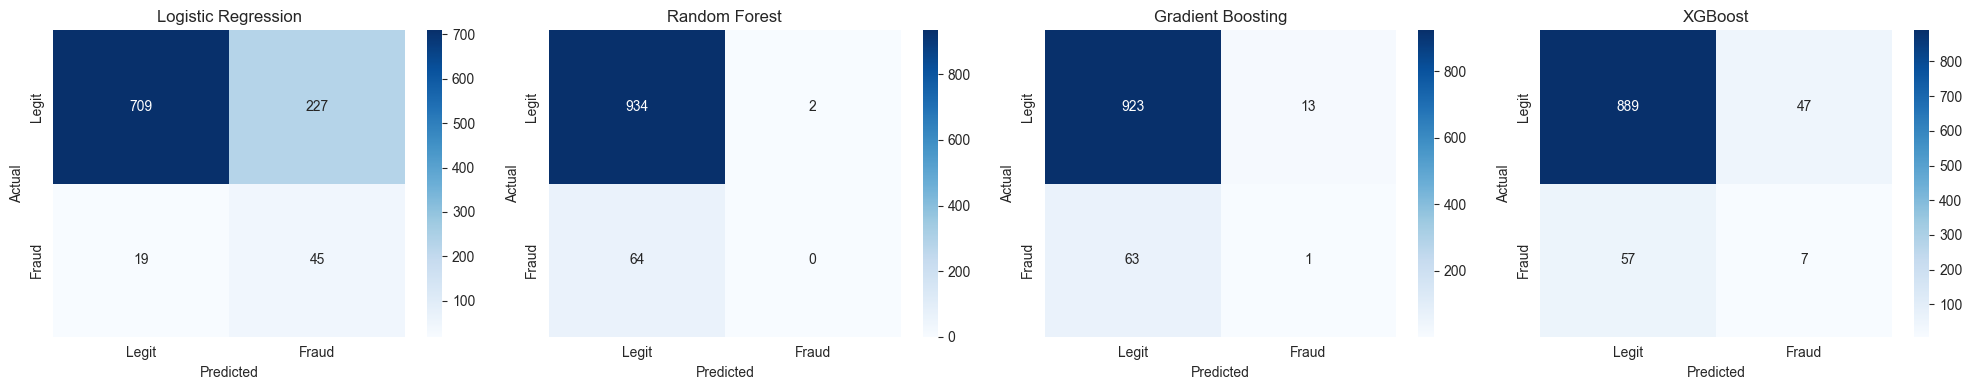

In [52]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

### 4.2 ROC Curves

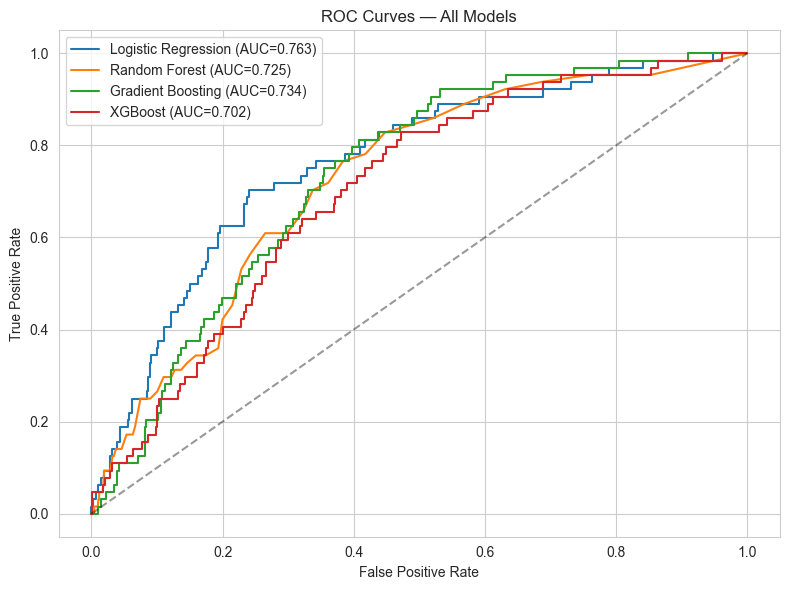

In [53]:
plt.figure(figsize=(8, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.tight_layout()
plt.show()

<a id='5'></a>
## 5. Evaluation — Model Selection & Hyperparameter Tuning (Ch. 15)

Based on the comparison above, **Random Forest** and **XGBoost** are the strongest performers. We tune the Random Forest with `RandomizedSearchCV` using 5-fold stratified cross-validation optimized for Recall.

In [54]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

tune_pipeline = Pipeline([
    ('preprocessor', build_preprocessor()),
    ('classifier', RandomForestClassifier(
        class_weight='balanced', random_state=42, n_jobs=-1
    )),
])

param_grid = {
    'classifier__n_estimators': [100, 200, 300, 400, 500],
    'classifier__max_depth': [4, 6, 8, 10, 12, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 4, 8],
    'classifier__max_features': ['sqrt', 'log2'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    tune_pipeline,
    param_distributions=param_grid,
    n_iter=30,
    scoring='recall',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)

print(f'Best CV Recall: {search.best_score_:.4f}')
print(f'Best params:    {search.best_params_}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/luke/Documents/School/Winter 2026/Machine Learning/DeploymentProject/website_pipeline/Website_Pipeline/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/luke/Documents/School/Winter 2026/Machine Learning/DeploymentProject/website_pipeline/Website_Pipeline/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/luke/Documents/School/Winter 2026/Machine Learning/DeploymentProject/website_pipeline/Website_Pipeline/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklear

Best CV Recall: 0.7003
Best params:    {'classifier__n_estimators': 400, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 4}


Tuned Random Forest — Test Set
              precision    recall  f1-score   support

       Legit       0.97      0.71      0.82       936
       Fraud       0.13      0.64      0.22        64

    accuracy                           0.70      1000
   macro avg       0.55      0.67      0.52      1000
weighted avg       0.91      0.70      0.78      1000

ROC-AUC: 0.7455


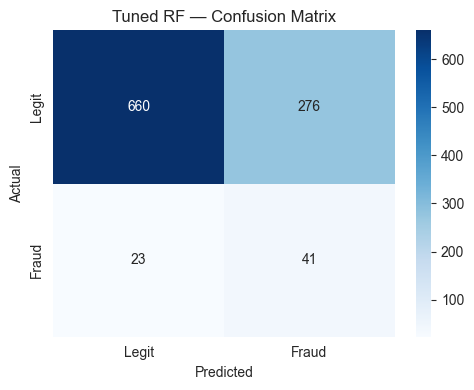

In [55]:
best_rf = search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)
y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]

print('Tuned Random Forest — Test Set')
print('=' * 50)
print(classification_report(y_test, y_pred_tuned, target_names=['Legit', 'Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}')

cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Tuned RF — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

<a id='6'></a>
## 6. Feature Selection (Ch. 16)

We use `SelectFromModel` with the tuned Random Forest to identify the most important features, then retrain on the reduced feature set to verify performance holds.

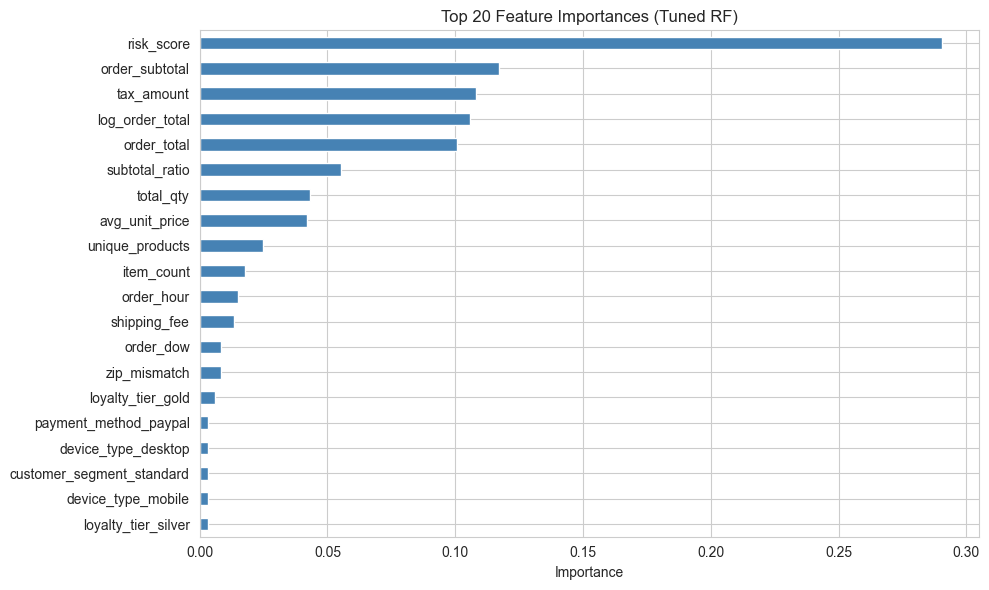

In [56]:
from sklearn.feature_selection import SelectFromModel

classifier = best_rf.named_steps['classifier']
pp = best_rf.named_steps['preprocessor']

num_names = NUMERIC_FEATURES
cat_names = pp.named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(CATEGORICAL_FEATURES).tolist()
all_pp_names = num_names + cat_names

importances = pd.Series(classifier.feature_importances_, index=all_pp_names)
top20 = importances.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top20.plot.barh(color='steelblue')
plt.title('Top 20 Feature Importances (Tuned RF)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [57]:
selector = SelectFromModel(classifier, prefit=True)

X_train_pp = pp.transform(X_train)
X_test_pp  = pp.transform(X_test)

X_train_selected = selector.transform(X_train_pp)
X_test_selected  = selector.transform(X_test_pp)

selected_mask = selector.get_support()
selected_names = [n for n, s in zip(all_pp_names, selected_mask) if s]
print(f'Features selected: {len(selected_names)} / {len(all_pp_names)}')
print(selected_names)

Features selected: 8 / 33
['order_subtotal', 'tax_amount', 'order_total', 'risk_score', 'total_qty', 'avg_unit_price', 'subtotal_ratio', 'log_order_total']


In [58]:
rf_selected = RandomForestClassifier(**classifier.get_params())
rf_selected.fit(X_train_selected, y_train)

y_pred_sel = rf_selected.predict(X_test_selected)
y_prob_sel = rf_selected.predict_proba(X_test_selected)[:, 1]

print('Random Forest on SELECTED Features — Test Set')
print('=' * 50)
print(classification_report(y_test, y_pred_sel, target_names=['Legit', 'Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_sel):.4f}')

Random Forest on SELECTED Features — Test Set
              precision    recall  f1-score   support

       Legit       0.97      0.70      0.82       936
       Fraud       0.13      0.66      0.22        64

    accuracy                           0.70      1000
   macro avg       0.55      0.68      0.52      1000
weighted avg       0.91      0.70      0.78      1000

ROC-AUC: 0.7515


<a id='7'></a>
## 7. Deployment (Ch. 17)

We serialize the best full-pipeline model (preprocessor + tuned RF) using `joblib`. This pipeline accepts raw feature DataFrames, so no separate preprocessing step is needed at inference time.

The same pipeline architecture is used in our production `jobs/run_inference.py` script, which the web application calls to score orders.

In [59]:
import joblib
from pathlib import Path

best_rf.fit(X, y)

model_path = Path('fraud_model_pipeline.joblib')
joblib.dump(best_rf, model_path)
print(f'Model saved to {model_path}  ({model_path.stat().st_size / 1024:.0f} KB)')

Model saved to fraud_model_pipeline.joblib  (1111 KB)


In [60]:
loaded_model = joblib.load(model_path)

sample = X.sample(5, random_state=99)
probs = loaded_model.predict_proba(sample)[:, 1]
preds = loaded_model.predict(sample)

demo = pd.DataFrame({
    'order_id': labeled.loc[sample.index, 'order_id'].values,
    'actual_is_fraud': y.loc[sample.index].values,
    'predicted_fraud': preds,
    'fraud_probability': probs,
})
print('Inference Demo — Loaded Pipeline')
demo

Inference Demo — Loaded Pipeline


,order_id,actual_is_fraud,predicted_fraud,fraud_probability
0,1035,0,1,0.648347
1,251,0,0,0.398966
2,2579,0,0,0.365049
3,3526,0,0,0.129128
4,3534,0,0,0.111133


### 7.1 Web Integration Architecture

The deployed web application invokes `python3 jobs/run_inference.py` via a Node.js Server Action. The inference script:

1. Loads the trained model from `jobs/model/model.pkl`
2. Loads all orders from `shop.db` and applies the same feature engineering (via `jobs/data_preparation.py`)
3. Generates predictions and upserts them into the `order_predictions` table
4. Prints `SCORED_ORDERS=<n>` to stdout so the web app knows how many orders were scored

This shared-module design means feature engineering logic is defined **once** in `jobs/data_preparation.py` and used by:
- This notebook (for exploration and training)
- `jobs/train.py` (for retraining the model)
- `jobs/run_inference.py` (for production scoring)

---

## Summary

| CRISP-DM Phase | What We Did |
|:---|:---|
| **Business Understanding** | Defined fraud detection as a binary classification with recall as the primary metric |
| **Data Understanding** | Loaded 6 tables from `shop.db`, explored distributions and correlations, identified class imbalance (~6.4% fraud) |
| **Data Preparation** | Joined tables, engineered 17 numeric + 5 categorical features, built `ColumnTransformer` preprocessing pipeline |
| **Modeling** | Trained Logistic Regression, Random Forest, Gradient Boosting, and XGBoost with balanced class weights |
| **Evaluation** | Compared models on Recall/F1/ROC-AUC, tuned best model (RF) with `RandomizedSearchCV` |
| **Feature Selection** | Used `SelectFromModel` to identify most predictive features, verified performance on reduced set |
| **Deployment** | Serialized pipeline with `joblib`, demonstrated inference, documented web integration architecture |